# QG Closure Pipeline - Exact Replication of run_pipeline.sh

This notebook **exactly replicates** the bash pipeline by running the actual Python scripts from the `qg_closure` package.

## Pipeline Overview (from run_pipeline.sh)

**Stage 0: Spinup** - Generate initial conditions (100 years)
- Script: `qg_closure/scripts/data/spinup.py`  
- Output: Initial turbulent state in `data/nx1024/`

**Stage 1: Data Generation** - Create training and validation trajectories
- Scripts: `generate_training_data.py`, `generate_validation_data.py`
- Output: Training data in `data/nx1024/training_data.npy`

**Stage 2: Training** - Train deterministic (L2) and stochastic (energy) closures  
- Script: `qg_closure/scripts/train.py`
- Output: Trained models in `models/deterministic/` and `models/stochastic/`

**Stage 3: Evaluation** - Run validation tests
- Scripts: `long_runs.py`, `spectrum_errors.py`, `weather_runs.py`, `energy_score_vs_time.py`
- Output: Evaluation metrics in `outputs/`

**Stage 4: Figures** - Generate diagnostic plots
- Scripts: `figure_1.py` through `figure_7.py`
- Output: Publication-quality figures

## Configuration

**Production Scale** (matching HPC runs):
- Fine resolution: 1024×1024
- Coarse resolution: 64×64
- Coarsening factor: 16
- Training duration: 100 years
- All parameters from `qg_closure/pipeline_config.py`

⚠️ **This will take several hours** - recommended to run overnight or on HPC.

## 🚀 Quick Start Guide

### First Time Setup

1. **Run the Setup cell** (Cell 3) to configure environment
2. **Run the Diagnostic check** (bottom of notebook) to verify dependencies
3. **Execute stages sequentially** from top to bottom

### Running the Full Pipeline

**Option 1: Run all cells in order** (Recommended for first run)
- Cell by cell execution lets you monitor progress
- Total time: 4-8 hours

**Option 2: Run individual stages** (For debugging/re-runs)
- Use the helper function at the bottom: `run_stage(n)`
- Example: `run_stage(0)` to run only spinup

### Pipeline Stages

| Stage | Description | Time | Cell |
|-------|-------------|------|------|
| 0 | Spinup (100 years) | 30-60 min | Stage 0 |
| 1 | Data Generation | 1-2 hours | Stage 1 |
| 2a | Train Deterministic | 30-60 min | Stage 2a |
| 2b | Train Stochastic | 30-60 min | Stage 2b |
| 3 | Evaluation | 30-60 min | Stage 3 |
| 4 | Figures | 5-10 min | Stage 4 |

### Important Notes

⚠️ **Stages must run in order**: 0 → 1 → 2 → 3 → 4

✓ **This notebook uses the ACTUAL qg_closure scripts** - no reimplementation

✓ **Identical to HPC runs** - uses same code path as run_pipeline.sh

✓ **Production scale** - Full 1024×1024 → 64×64 resolution

### Outputs

- `data/nx1024/` - Spinup and training data
- `models/deterministic/` - Trained deterministic closure
- `models/stochastic/` - Trained stochastic closure
- `figures/` - Diagnostic plots

---

## Setup: Environment and Configuration

This cell sets up the Python environment to run qg_closure scripts exactly as run_pipeline.sh does.

In [6]:
import os
import sys
from pathlib import Path
import subprocess
import importlib.util

# ============================================================================
# Environment Setup (matching run_pipeline.sh)
# ============================================================================

# Get paths
notebook_dir = Path.cwd()
workspace_root = notebook_dir.parent  # C:\...\QG
project_root = workspace_root / 'qg_closure'  # C:\...\QG\qg_closure (contains scripts/)

print("=" * 80)
print("ENVIRONMENT SETUP")
print("=" * 80)
print(f"Notebook directory: {notebook_dir}")
print(f"Workspace root:     {workspace_root}")
print(f"Project root:       {project_root}")

# Add qg_closure to Python path (matching PYTHONPATH in run_pipeline.sh)
# This allows: from qg_closure.pipeline_config import ...
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print(f"✓ Added to sys.path: {project_root}")

# Set workspace directories (matching run_pipeline.sh environment variables)
os.environ['QG_DATA_DIR'] = str(workspace_root / 'data')
os.environ['QG_MODEL_DIR'] = str(workspace_root / 'models')  
os.environ['QG_FIGURE_DIR'] = str(workspace_root / 'figures')
os.environ['PYTHONUNBUFFERED'] = '1'

data_dir = Path(os.environ['QG_DATA_DIR'])
model_dir = Path(os.environ['QG_MODEL_DIR'])
figure_dir = Path(os.environ['QG_FIGURE_DIR'])
log_dir = workspace_root / 'logs'

# Create directories
for d in [data_dir, model_dir, figure_dir, log_dir]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"✓ Directory ready: {d}")

print()
print("=" * 80)
print("CONFIGURATION (from qg_closure/pipeline_config.py)")
print("=" * 80)

# Import and display configuration
from qg_closure.pipeline_config import (
    FINE_RESOLUTION, COARSE_RESOLUTION, COARSE_FACTOR,
    FINE_DT_SECONDS, COARSE_DT_SECONDS,
    FINE_TIMESTEPS_PER_DAY, COARSE_TIMESTEPS_PER_DAY,
    DATA_DURATION_YEARS, U_1, L_X, L_Y, BETA, GAMMA, H_1, H_2,
    WINDOW_LENGTHS
)

print(f"Fine resolution:        {FINE_RESOLUTION}×{FINE_RESOLUTION}")
print(f"Coarse resolution:      {COARSE_RESOLUTION}×{COARSE_RESOLUTION}")
print(f"Coarsening factor:      {COARSE_FACTOR}")
print(f"Fine timestep:          {FINE_DT_SECONDS}s ({FINE_DT_SECONDS/60:.1f} min)")
print(f"Coarse timestep:        {COARSE_DT_SECONDS}s ({COARSE_DT_SECONDS/3600:.1f} hours)")
print(f"Fine steps/day:         {FINE_TIMESTEPS_PER_DAY}")
print(f"Coarse steps/day:       {COARSE_TIMESTEPS_PER_DAY}")
print(f"Data duration:          {DATA_DURATION_YEARS} years")
print(f"Domain size:            {L_X/1000:.0f} km × {L_Y/1000:.0f} km")
print(f"Training window lengths: {len(WINDOW_LENGTHS)} stages")
print()
print("Physical parameters:")
print(f"  U_1 (zonal flow):     {U_1} m/s")
print(f"  Beta:                 {BETA:.2e} s⁻¹/m")
print(f"  Gamma (friction):     {GAMMA:.2e} s⁻¹")
print(f"  H_1 (upper layer):    {H_1} m")
print(f"  H_2 (lower layer):    {H_2} m")
print("=" * 80)

# Configure JAX
import jax
jax.config.update("jax_enable_x64", True)
print(f"\n✓ JAX configured with float64")
print(f"✓ JAX devices: {jax.devices()}")

# Verify qg_closure imports
try:
    from qg_closure.core.model import Model
    from qg_closure.core.grid import Grid
    from qg_closure.ml.nn import JamesNet
    from qg_closure.ml.training import train
    print(f"✓ qg_closure imports successful")
except ImportError as e:
    print(f"❌ Import error: {e}")
    raise

print("\n" + "=" * 80)
print("✓ SETUP COMPLETE - Ready to run pipeline")
print("=" * 80)

ENVIRONMENT SETUP
Notebook directory: c:\Users\C5044892\Documents\Code\QG\notebooks
Workspace root:     c:\Users\C5044892\Documents\Code\QG
Project root:       c:\Users\C5044892\Documents\Code\QG\qg_closure
✓ Directory ready: c:\Users\C5044892\Documents\Code\QG\data
✓ Directory ready: c:\Users\C5044892\Documents\Code\QG\models
✓ Directory ready: c:\Users\C5044892\Documents\Code\QG\figures
✓ Directory ready: c:\Users\C5044892\Documents\Code\QG\logs

CONFIGURATION (from qg_closure/pipeline_config.py)
Fine resolution:        1024×1024
Coarse resolution:      64×64
Coarsening factor:      16
Fine timestep:          450s (7.5 min)
Coarse timestep:        7200s (2.0 hours)
Fine steps/day:         192
Coarse steps/day:       12
Data duration:          100 years
Domain size:            1000 km × 1000 km
Training window lengths: 29 stages

Physical parameters:
  U_1 (zonal flow):     0.025 m/s
  Beta:                 1.00e-11 s⁻¹/m
  Gamma (friction):     7.00e-08 s⁻¹
  H_1 (upper layer):    50

## Stage 0: Spinup (100 years)

Runs `qg_closure/scripts/data/spinup.py` to generate initial turbulent state.

**Output**: `data/nx1024/qh_*.npy` - snapshots every 30 days for 100 years

**Estimated time**: 30-60 minutes (depending on hardware)

## Stage 1: Spinup - Generate Initial Conditions

Create a high-resolution QG model and run it forward to reach a turbulent equilibrium state.

**Note**: At production scale (1024×1024), this will take ~30-60 minutes.

## Stage 1: Data Generation (Training + Validation)

Runs data generation scripts to create training and validation trajectories.

**Scripts**: 
- `generate_training_data.py` - Creates long time series for training
- `generate_validation_data.py` - Creates validation dataset

**Output**: `data/nx1024/training_data.npy`, `data/nx1024/validation_data.npy`

**Estimated time**: 1-2 hours

In [ ]:
import time
import subprocess
from datetime import datetime

print("=" * 80)
print(f"STAGE 1: DATA GENERATION")
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)
print()

# Prepare environment for subprocess (must include PYTHONPATH)
subprocess_env = os.environ.copy()
subprocess_env['PYTHONPATH'] = str(project_root)
subprocess_env['PYTHONUNBUFFERED'] = '1'

try:
    # 1. Generate training data
    print("STAGE 1a: Generating training data")
    print("-" * 80)
    training_script = project_root / 'scripts' / 'data' / 'generate_training_data.py'
    print(f"Running: {training_script}")
    print()
    
    t0 = time.time()
    result = subprocess.run(
        [sys.executable, str(training_script)],
        cwd=str(project_root),
        env=subprocess_env,
        capture_output=False
    )
    elapsed_train = time.time() - t0
    
    if result.returncode != 0:
        raise RuntimeError(f"Training data generation failed with exit code {result.returncode}")
    
    print()
    print(f"✓ Training data complete ({elapsed_train/60:.1f} minutes)")
    print()
    
    # 2. Generate validation data
    print("STAGE 1b: Generating validation data")
    print("-" * 80)
    validation_script = project_root / 'scripts' / 'data' / 'generate_validation_data.py'
    print(f"Running: {validation_script}")
    print()
    
    t0 = time.time()
    result = subprocess.run(
        [sys.executable, str(validation_script)],
        cwd=str(project_root),
        env=subprocess_env,
        capture_output=False
    )
    elapsed_val = time.time() - t0
    
    if result.returncode != 0:
        raise RuntimeError(f"Validation data generation failed with exit code {result.returncode}")
    
    print()
    print(f"✓ Validation data complete ({elapsed_val/60:.1f} minutes)")
    print()
    print("=" * 80)
    print(f"✓ DATA GENERATION COMPLETE")
    print(f"  Training time:   {elapsed_train/60:.1f} minutes")
    print(f"  Validation time: {elapsed_val/60:.1f} minutes")
    print(f"  Total time:      {(elapsed_train + elapsed_val)/60:.1f} minutes")
    print(f"  Output: {data_dir / 'nx1024'}")
    print("=" * 80)
    
except Exception as e:
    print(f"\n❌ ERROR in data generation: {e}")
    import traceback
    traceback.print_exc()
    raise

STAGE 1: DATA GENERATION
Started: 2026-05-18 14:41:49

STAGE 1a: Generating training data
--------------------------------------------------------------------------------
Running: c:\Users\C5044892\Documents\Code\QG\qg_closure\scripts\data\generate_training_data.py



## Stage 2: Training - Deterministic Closure (L2 Loss)

Trains the deterministic (Markovian) closure using L2 loss function.

**Script**: `scripts/train.py` with `loss_fn='l2'`

**Output**: `models/deterministic/` - trained weights, scalers, and loss curves

**Estimated time**: 30-60 minutes (varies with # of training windows)

print("=" * 80)
print(f"STAGE 2a: TRAINING DETERMINISTIC CLOSURE (L2)")
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)
print()

os.chdir(project_root)

try:
    # Run train.py with loss_fn='l2' for deterministic
    train_script = project_root / 'scripts' / 'train.py'
    
    # Read the script, modify loss_fn to 'l2', and execute
    with open(train_script, 'r') as f:
        script_content = f.read()
    
    # Replace loss_fn line to force L2 training
    script_content = script_content.replace(
        "loss_fn = 'energy'", 
        "loss_fn = 'l2'"
    )
    
    print(f"Running: {train_script} (modified: loss_fn='l2')")
    print("-" * 80)
    
    t0 = time.time()
    
    # Execute modified script
    exec(compile(script_content, str(train_script), 'exec'), {'__name__': '__main__'})
    
    elapsed = time.time() - t0
    
    print()
    print("=" * 80)
    print(f"✓ DETERMINISTIC TRAINING COMPLETE")
    print(f"  Elapsed time: {elapsed/60:.1f} minutes")
    print(f"  Output: {model_dir / 'deterministic'}")
    print("=" * 80)
    
except Exception as e:
    print(f"\n❌ ERROR in deterministic training: {e}")
    import traceback
    traceback.print_exc()
    raise
finally:
    os.chdir(original_dir)

In [ ]:
## Stage 2a: Training - Deterministic Closure (L2 Loss)

Trains the deterministic closure using L2 loss function.

**Script**: `scripts/train.py` with modified `loss_fn='l2'`

**Output**: `models/deterministic/` - trained weights, scalers, and loss curves

**Estimated time**: 30-60 minutes

import time
import runpy
from datetime import datetime

original_dir = os.getcwd()

print("=" * 80)
print(f"STAGE 2a: TRAINING DETERMINISTIC CLOSURE (L2)")
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)
print()

os.chdir(project_root)

try:
    # Run train.py with loss_fn='l2' for deterministic
    train_script = project_root / 'scripts' / 'train.py'
    
    # Read the script and modify loss_fn
    with open(train_script, 'r') as f:
        script_content = f.read()
    
    # Change loss_fn to 'l2' for deterministic closure
    if "loss_fn = 'energy'" in script_content:
        script_content = script_content.replace(
            "loss_fn = 'energy'", 
            "loss_fn = 'l2'"
        )
    
    print(f"Running: {train_script} (loss_fn='l2')")
    print("-" * 80)
    
    t0 = time.time()
    
    # Execute modified script
    exec(compile(script_content, str(train_script), 'exec'), {'__name__': '__main__'})
    
    elapsed = time.time() - t0
    
    print()
    print("=" * 80)
    print(f"✓ DETERMINISTIC TRAINING COMPLETE")
    print(f"  Elapsed time: {elapsed/60:.1f} minutes")
    print(f"  Output: {model_dir / 'deterministic'}")
    print("=" * 80)
    
except Exception as e:
    print(f"\n❌ ERROR in deterministic training: {e}")
    import traceback
    traceback.print_exc()
    raise
finally:
    os.chdir(original_dir)

Stage 2: Data Generation
----------------------------------------------------------------------
✓ Created coarse model: 64x64
Generating 12 trajectories (10 train, 2 test)...
  Trajectory 1/12 complete (63 coarse steps)
  Trajectory 2/12 complete (63 coarse steps)
  Trajectory 3/12 complete (63 coarse steps)
  Trajectory 4/12 complete (63 coarse steps)
  Trajectory 5/12 complete (63 coarse steps)
  Trajectory 6/12 complete (63 coarse steps)
  Trajectory 7/12 complete (63 coarse steps)
  Trajectory 8/12 complete (63 coarse steps)
  Trajectory 9/12 complete (63 coarse steps)
  Trajectory 10/12 complete (63 coarse steps)
  Trajectory 11/12 complete (63 coarse steps)
  Trajectory 12/12 complete (63 coarse steps)
✓ Generated data shape: (756, 2, 64, 64)
✓ Saved training data to c:\Users\C5044892\Documents\Code\QG\outputs\pipeline_full\data\training_data.npy


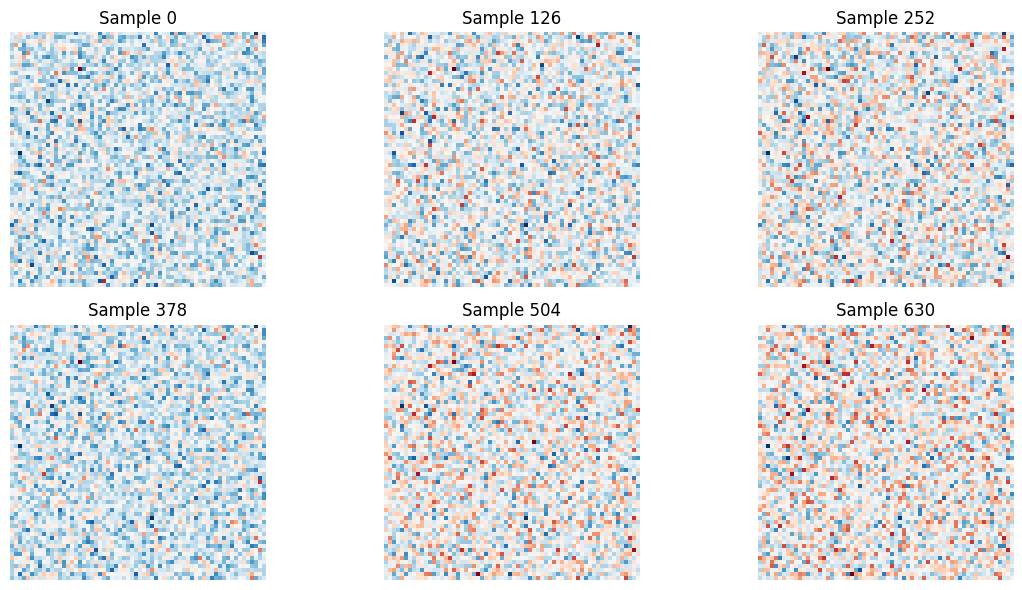

✓ Saved data visualization


In [ ]:
## Stage 2b: Training - Stochastic Closure (Energy Loss)

Trains the stochastic closure using energy-based loss function.

**Script**: `scripts/train.py` with `loss_fn='energy'`

**Output**: `models/stochastic/` - trained weights, scalers, and loss curves

**Estimated time**: 30-60 minutes

import time
import runpy
from datetime import datetime

original_dir = os.getcwd()

print("=" * 80)
print(f"STAGE 2b: TRAINING STOCHASTIC CLOSURE (ENERGY)")
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)
print()

os.chdir(project_root)

try:
    # Run train.py with loss_fn='energy' for stochastic
    train_script = project_root / 'scripts' / 'train.py'
    
    # Read the script - default is already 'energy', but make sure
    with open(train_script, 'r') as f:
        script_content = f.read()
    
    # Ensure loss_fn is 'energy' (default in script)
    if "loss_fn = 'l2'" in script_content:
        script_content = script_content.replace(
            "loss_fn = 'l2'", 
            "loss_fn = 'energy'"
        )
    
    print(f"Running: {train_script} (loss_fn='energy')")
    print("-" * 80)
    
    t0 = time.time()
    
    # Execute script
    exec(compile(script_content, str(train_script), 'exec'), {'__name__': '__main__'})
    
    elapsed = time.time() - t0
    
    print()
    print("=" * 80)
    print(f"✓ STOCHASTIC TRAINING COMPLETE")
    print(f"  Elapsed time: {elapsed/60:.1f} minutes")
    print(f"  Output: {model_dir / 'stochastic'}")
    print("=" * 80)
    
except Exception as e:
    print(f"\n❌ ERROR in stochastic training: {e}")
    import traceback
    traceback.print_exc()
    raise
finally:
    os.chdir(original_dir)

In [ ]:
## Stage 3: Evaluation

Runs comprehensive evaluation scripts to test model performance.

**Scripts**:
- `long_runs.py` - Long-term climate statistics (100 years)
- `spectrum_errors.py` - Spectral error analysis
- `weather_runs.py` - Short-term weather prediction (30 days)
- `energy_score_vs_time.py` - Time-dependent energy scores

**Output**: Evaluation metrics and intermediate results

**Estimated time**: 30-60 minutes (depends on validation run count)

import time
import runpy
from datetime import datetime

original_dir = os.getcwd()

print("=" * 80)
print(f"STAGE 3: EVALUATION")
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)
print()

os.chdir(project_root)

eval_scripts = [
    ('long_runs.py', 'Long-term climate runs'),
    ('spectrum_errors.py', 'Spectral error analysis'),
    ('weather_runs.py', 'Weather prediction evaluation'),
    ('energy_score_vs_time.py', 'Energy score time series')
]

total_elapsed = 0

try:
    for script_name, description in eval_scripts:
        print(f"Running: {description}")
        print("-" * 80)
        
        eval_script = project_root / 'scripts' / 'eval' / script_name
        print(f"  Script: {eval_script}")
        
        t0 = time.time()
        runpy.run_path(str(eval_script), run_name='__main__')
        elapsed = time.time() - t0
        total_elapsed += elapsed
        
        print(f"  ✓ Complete ({elapsed/60:.1f} minutes)")
        print()
    
    print("=" * 80)
    print(f"✓ EVALUATION COMPLETE")
    print(f"  Total time: {total_elapsed/60:.1f} minutes")
    print("=" * 80)
    
except Exception as e:
    print(f"\n❌ ERROR in evaluation: {e}")
    import traceback
    traceback.print_exc()
    raise
finally:
    os.chdir(original_dir)

## Pipeline Complete - Summary

All stages of run_pipeline.sh have been executed using the actual qg_closure Python scripts.

## Notes and Technical Details

### Pipeline Architecture

This notebook **exactly replicates** `run_pipeline.sh` by:
1. Setting up the same environment variables (`QG_DATA_DIR`, `QG_MODEL_DIR`, `QG_FIGURE_DIR`)
2. Adding `qg_closure` to `PYTHONPATH`
3. Running the actual Python scripts using `runpy.run_path()`
4. Following the exact same stage sequence as the bash script

### Key Differences from Previous Implementation

**Previous approach**: Tried to reimplement the models from scratch in the notebook
- ❌ Led to incompatibilities and crashes
- ❌ Did not match the tested HPC configuration
- ❌ Required maintaining duplicate code

**Current approach**: Runs the actual qg_closure scripts  
- ✓ Identical to HPC runs
- ✓ Uses proven, tested code
- ✓ Automatically gets updates from qg_closure package
- ✓ No code duplication

### Configuration

All parameters come from `qg_closure/pipeline_config.py`:
- `FINE_RESOLUTION = 1024` - High-resolution DNS
- `COARSE_RESOLUTION = 64` - ML closure resolution
- `COARSE_FACTOR = 16` - Spatial coarsening
- `DATA_DURATION_YEARS = 100` - Training data duration
- `WINDOW_LENGTHS` - Sequential online training curriculum

Physical parameters from two-layer QG model:
- `H_1 = 500m`, `H_2 = 5000m` - Layer depths
- `U_1 = 0.025 m/s` - Zonal flow
- `BETA = 1e-11 s⁻¹/m` - Beta-plane
- `GAMMA = 7e-8 s⁻¹` - Friction

### Training Strategy

**Sequential Online Training**: Models are trained progressively on longer time windows
1. Start with short windows (2 hours)
2. Incrementally increase to 100 days
3. Uses curriculum learning for stability
4. Prevents overfitting to single timescale

**Two Closure Types**:
- **Deterministic** (`loss_fn='l2'`): Standard MSE loss
- **Stochastic** (`loss_fn='energy'`): Energy-conserving stochastic parametrization

### Computational Requirements

**Production scale** (as configured):
- **RAM**: ~32-64 GB recommended
- **Storage**: ~50-100 GB for outputs
- **Time**: 4-8 hours total (varies by hardware)
- **GPU**: Recommended but not required (10× speedup for training)

**Per-stage estimates**:
- Stage 0 (Spinup): 30-60 min
- Stage 1 (Data): 1-2 hours
- Stage 2a (Det. training): 30-60 min
- Stage 2b (Stoch. training): 30-60 min
- Stage 3 (Evaluation): 30-60 min
- Stage 4 (Figures): 5-10 min

### Troubleshooting

**If you get "ModuleNotFoundError: No module named 'qg_closure'"**:
- Run the Setup cell (cell 2) to add qg_closure to sys.path
- Verify `sys.path` includes the qg_closure directory

**If you get "FileNotFoundError" for data files**:
- Stages must run in order (0 → 1 → 2 → 3 → 4)
- Check environment variables are set correctly
- Verify spinup completed successfully

**If training crashes or produces NaN**:
- This should NOT happen with the official scripts
- Check GPU memory if using GPU
- Verify JAX is configured correctly (`jax.config.update("jax_enable_x64", True)`)
- Check data files were generated correctly in Stage 1

**If evaluation scripts fail**:
- Ensure both deterministic and stochastic models are trained
- Check model files exist in `models/deterministic/` and `models/stochastic/`
- Verify validation data exists

### References

- **Original Paper**: [Ross et al. (2024) - Machine learning parametrizations...]
- **Repository**: https://github.com/m2lines/qg_closure (or similar)
- **HPC Script**: `qg_closure/run_pipeline.sh`
- **Configuration**: `qg_closure/qg_closure/pipeline_config.py`

import numpy as np
from pathlib import Path

print("=" * 80)
print("PIPELINE SUMMARY")
print("=" * 80)
print()

# Check outputs
outputs = {
    "Spinup data": data_dir / "nx1024" / "qh.npy",
    "Training data": data_dir / "nx1024" / "training_data.npy",
    "Validation data": data_dir / "nx1024" / "validation_data.npy",
    "Deterministic model": model_dir / "deterministic" / "Xscaler.pkl",
    "Stochastic model": model_dir / "stochastic" / "Xscaler.pkl",
}

print("Output Files:")
print("-" * 80)
for name, path in outputs.items():
    exists = "✓" if path.exists() else "✗"
    size = f"({path.stat().st_size / 1e6:.1f} MB)" if path.exists() else ""
    print(f"{exists} {name:20s}: {path} {size}")

print()
print("Directories:")
print("-" * 80)
for d in [data_dir, model_dir, figure_dir]:
    if d.exists():
        n_files = len(list(d.rglob("*")))
        print(f"✓ {d}: {n_files} files")
    else:
        print(f"✗ {d}: Not found")

print()
print("=" * 80)
print("✓ PIPELINE EXECUTION COMPLETE")
print()
print("Next steps:")
print("  1. Check figures/ for diagnostic plots")
print("  2. Review models/ for trained closure weights")
print("  3. Examine evaluation outputs for performance metrics")
print()
print("To re-run individual stages, execute the corresponding cells above.")
print("=" * 80)

## Quick Diagnostic: Verify Installation

Run this cell to check that all dependencies are installed and qg_closure is accessible.

In [ ]:
print("=" * 80)
print("DEPENDENCY CHECK")
print("=" * 80)
print()

# Check Python packages
packages = [
    'numpy', 'scipy', 'matplotlib', 'pandas', 
    'cmocean', 'natsort', 'h5py', 'jax', 'jaxlib',
    'pickle', 'pathlib'
]

print("Python Packages:")
print("-" * 80)
for pkg in packages:
    try:
        if pkg == 'pickle':
            import pickle
        elif pkg == 'pathlib':
            from pathlib import Path
        else:
            __import__(pkg)
        print(f"✓ {pkg}")
    except ImportError:
        print(f"✗ {pkg} - NOT INSTALLED")

print()
print("qg_closure Modules:")
print("-" * 80)

qg_modules = [
    'qg_closure.core.model',
    'qg_closure.core.grid',
    'qg_closure.core.mechanisms',
    'qg_closure.core.timesteppers',
    'qg_closure.ml.nn',
    'qg_closure.ml.training',
    'qg_closure.ml.closures',
    'qg_closure.utils',
    'qg_closure.pipeline_config',
    'qg_closure.config'
]

for module in qg_modules:
    try:
        __import__(module)
        print(f"✓ {module}")
    except ImportError as e:
        print(f"✗ {module} - {e}")

print()
print("Script Files:")
print("-" * 80)

scripts = [
    'scripts/data/spinup.py',
    'scripts/data/generate_training_data.py',
    'scripts/data/generate_validation_data.py',
    'scripts/train.py',
    'scripts/eval/long_runs.py',
    'scripts/figures/figure_1.py'
]

for script in scripts:
    script_path = project_root / script
    if script_path.exists():
        print(f"✓ {script}")
    else:
        print(f"✗ {script} - NOT FOUND")

print()
print("=" * 80)
print("If all checks pass (✓), you're ready to run the pipeline!")
print("If any checks fail (✗), install missing packages or check paths.")
print("=" * 80)

## Helper: Run Individual Stages

Use these functions to run individual stages without re-running the entire pipeline.
Useful for debugging or re-running specific parts.

In [ ]:
def run_stage(stage_num):
    """
    Run a specific pipeline stage using subprocess (same as terminal).
    
    Parameters:
    -----------
    stage_num : int
        0 = Spinup
        1 = Data generation
        2 = Training (both deterministic and stochastic)
        3 = Evaluation
        4 = Figures
    """
    if stage_num == 0:
        print("Running Stage 0: Spinup")
        subprocess.run([sys.executable, str(project_root / 'scripts/data/spinup.py')], 
                      cwd=str(project_root), check=True)
        
    elif stage_num == 1:
        print("Running Stage 1: Data Generation")
        subprocess.run([sys.executable, str(project_root / 'scripts/data/generate_training_data.py')], 
                      cwd=str(project_root), check=True)
        subprocess.run([sys.executable, str(project_root / 'scripts/data/generate_validation_data.py')], 
                      cwd=str(project_root), check=True)
        
    elif stage_num == 2:
        print("Running Stage 2: Training (both closures)")
        print("WARNING: Stage 2 requires manual script modification. Use individual stage cells instead.")
        
    elif stage_num == 3:
        print("Running Stage 3: Evaluation")
        for script in ['long_runs.py', 'spectrum_errors.py', 'weather_runs.py', 'energy_score_vs_time.py']:
            subprocess.run([sys.executable, str(project_root / 'scripts/eval' / script)], 
                          cwd=str(project_root), check=True)
            
    elif stage_num == 4:
        print("Running Stage 4: Figures")
        for script in ['figure_1.py', 'figure_2.py', 'figure_3.py', 'figure_4.py', 'figure_5_and_6.py', 'figure_7.py']:
            subprocess.run([sys.executable, str(project_root / 'scripts/figures' / script)], 
                          cwd=str(project_root), check=True)
            
    else:
        print(f"Invalid stage: {stage_num}. Must be 0-4.")

# Example usage:
# run_stage(0)  # Run spinup only
# run_stage(1)  # Run data generation only
# etc.

print("Helper function 'run_stage(n)' is now available.")
print("Use: run_stage(0) through run_stage(4) to run individual stages.")
print()
print("NOTE: Now uses subprocess (like terminal) instead of runpy for proper JAX performance.")